<a href="https://colab.research.google.com/github/Lunidep/analitics-ai/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №2
## «Виртуальный датчик для контроля процесса обжига в печи»

#### Выполнил студент группы М8О-209СВ-24 Попов Илья Павлович

`data_train.csv` — минутные измерения 16 показателей телеметрии за 8 месяцев для обучения

`target_train.csv` — лабораторные замеры концентрации целевого продукта (нерегулярные, с задержкой 10-15 мин)

`data_test_small.csv`, `target_test_small.csv` — аналогичные данные для тестирования

## 1. Импорт библиотек и настройка окружения

## 2.1 Разведочный анализ данных (EDA)

In [124]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, kstest

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False

DATA_TRAIN_PATH = 'data_train.csv'
TARGET_TRAIN_PATH = 'target_train.csv'
DATA_TEST_PATH = 'data_test_small.csv'
TARGET_TEST_PATH = 'target_test_small.csv'

CONFIG = {
    # Диапазон задержек для подбора (в минутах)
    'delay_candidates_min': [10, 11, 12, 13, 14, 15],

    # Лаги для построения признаков (в минутах)
    'lag_list_min': [1, 5, 10, 15, 30, 60],

    # Окна для скользящих статистик (в минутах)
    'rolling_windows_min': [10, 20, 30, 60],

    # Порог для удаления признаков с большим количеством пропусков
    'drop_col_missing_ratio_threshold': 0.95,

    # Доля обучающей выборки при time-based split
    'train_fraction': 0.80,

    # Seed для воспроизводимости
    'random_seed': 42,

    # Параметры моделей
    'delay_tune_n_estimators': 200,
    'extra_trees_n_estimators': 800,
    'rf_n_estimators': 800,
    'gb_n_estimators': 500,
}

np.random.seed(CONFIG['random_seed'])

### Общий анализ

In [125]:
telemetry_raw = pd.read_csv(DATA_TRAIN_PATH)
target_raw = pd.read_csv(TARGET_TRAIN_PATH)

telemetry_raw['datetime'] = pd.to_datetime(telemetry_raw['datetime'])
target_raw['Дата'] = pd.to_datetime(target_raw['Дата'])

report = [
    "=" * 60,
    "ОТЧЕТ ПО ЗАГРУЗКЕ ДАННЫХ",
    "=" * 60,
    "\n[Телеметрия]",
    f"Общее количество записей: {len(telemetry_raw):,}",
    f"Уникальные временные метки: {telemetry_raw['datetime'].nunique():,}",
    f"Дубликаты по времени: {telemetry_raw.duplicated('datetime').sum():,}",
    f"Период: {telemetry_raw['datetime'].min().date()} — {telemetry_raw['datetime'].max().date()}",
    f"Длительность: {(telemetry_raw['datetime'].max() - telemetry_raw['datetime'].min()).days} дн.",
    "\n[Целевая переменная]",
    f"Всего замеров: {len(target_raw):,}",
    f"Период: {target_raw['Дата'].min().date()} — {target_raw['Дата'].max().date()}",
    f"Среднее: {target_raw['target'].mean():.4f}",
    f"Стд. отклонение: {target_raw['target'].std():.4f}",
    f"Диапазон: [{target_raw['target'].min():.4f}, {target_raw['target'].max():.4f}]",
    "=" * 60
]

print("\n".join(report))
telemetry_raw.info()

ОТЧЕТ ПО ЗАГРУЗКЕ ДАННЫХ

[Телеметрия]
Общее количество записей: 319,546
Уникальные временные метки: 317,998
Дубликаты по времени: 1,548
Период: 2019-03-01 — 2019-10-07
Длительность: 220 дн.

[Целевая переменная]
Всего замеров: 1,773
Период: 2019-03-13 — 2019-10-07
Среднее: 0.2543
Стд. отклонение: 0.0922
Диапазон: [0.0000, 0.7165]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319546 entries, 0 to 319545
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   datetime      319546 non-null  datetime64[ns]
 1   telemetry_0   319529 non-null  float64       
 2   telemetry_1   319530 non-null  float64       
 3   telemetry_2   319530 non-null  float64       
 4   telemetry_3   319530 non-null  float64       
 5   telemetry_4   319413 non-null  float64       
 6   telemetry_5   319529 non-null  float64       
 7   telemetry_6   319530 non-null  float64       
 8   telemetry_7   319530 non-null  float64   

### Пропуски

In [126]:
# Агрегация дубликатов по времени (усреднение)
telemetry_raw = (
    telemetry_raw
    .groupby('datetime', as_index=False)
    .mean(numeric_only=True)
    .sort_values('datetime')
    .set_index('datetime')
)

# Выделение телеметрических колонок
telemetry_cols = [c for c in telemetry_raw.columns if c.startswith('telemetry_')]

# Расчет статистики пропусков
missing_stats = telemetry_raw[telemetry_cols].isna().sum()
total_rows = len(telemetry_raw)
missing_ratio = (missing_stats / total_rows * 100).sort_values(ascending=False)

# Формирование таблицы для вывода
missing_df = pd.DataFrame({
    'Канал': missing_ratio.index.tolist(),
    'Пропущено (шт)': missing_stats.loc[missing_ratio.index].values,
    'Доля пропусков (%)': missing_ratio.values
})

print(f"\nСтатистика пропусков по каналам (всего: {len(telemetry_cols)}):")
print(missing_df.to_string(index=False))

# Фильтрация каналов по порогу пропусков
threshold = CONFIG['drop_col_missing_ratio_threshold'] * 100  # конвертация в проценты для наглядности
keep_mask = missing_ratio <= (CONFIG['drop_col_missing_ratio_threshold'] * 100)
keep_cols = keep_mask[keep_mask].index.tolist()
dropped_cols = [c for c in telemetry_cols if c not in keep_cols]

print(f"\nРезультаты фильтрации (порог: {CONFIG['drop_col_missing_ratio_threshold']*100:.1f}%):")
print(f"  Оставлено каналов: {len(keep_cols)}")
print(f"  Удалено каналов: {len(dropped_cols)}")
if dropped_cols:
    print(f"  Исключенные: {', '.join(dropped_cols)}")

# Применение фильтрации
telemetry_raw = telemetry_raw[keep_cols].copy()

# Интерполяция пропусков
telemetry_raw = telemetry_raw.interpolate(method='time', limit_direction='both')
telemetry_raw = telemetry_raw.ffill().bfill()

remaining_missing = telemetry_raw.isna().sum().sum()
print(f"\nИнтерполяция завершена. Оставшиеся пропуски: {int(remaining_missing)}")


Статистика пропусков по каналам (всего: 16):
       Канал  Пропущено (шт)  Доля пропусков (%)
telemetry_12          315901           99.340562
telemetry_13          315901           99.340562
telemetry_14          315901           99.340562
telemetry_15          315901           99.340562
 telemetry_4             133            0.041824
 telemetry_0              17            0.005346
 telemetry_5              17            0.005346
 telemetry_1              16            0.005031
 telemetry_7              16            0.005031
 telemetry_6              16            0.005031
 telemetry_2              16            0.005031
 telemetry_3              16            0.005031
telemetry_11              16            0.005031
telemetry_10              16            0.005031
 telemetry_9              16            0.005031
 telemetry_8              16            0.005031

Результаты фильтрации (порог: 95.0%):
  Оставлено каналов: 12
  Удалено каналов: 4
  Исключенные: telemetry_12, telemetr

### Выбросы

In [127]:
# Обработка выбросов методом Winsorization
q_low, q_high = 0.01, 0.99
outlier_data = []

for col in telemetry_raw.columns:
    lo = telemetry_raw[col].quantile(q_low)
    hi = telemetry_raw[col].quantile(q_high)

    # Подсчет выбросов до обрезки
    outliers_count = ((telemetry_raw[col] < lo) | (telemetry_raw[col] > hi)).sum()
    outliers_pct = (outliers_count / len(telemetry_raw)) * 100

    outlier_data.append({
        'Канал': col,
        'Выбросов (шт)': int(outliers_count),
        'Доля (%)': round(outliers_pct, 2)
    })

    telemetry_raw[col] = telemetry_raw[col].clip(lo, hi)

outlier_df = pd.DataFrame(outlier_data).sort_values('Выбросов (шт)', ascending=False)
print(f"\nСтатистика выбросов до обработки (квантили {q_low}-{q_high}):")
print(outlier_df.to_string(index=False))


Статистика выбросов до обработки (квантили 0.01-0.99):
       Канал  Выбросов (шт)  Доля (%)
 telemetry_5           6293      1.98
 telemetry_8           6259      1.97
 telemetry_2           6166      1.94
 telemetry_0           6037      1.90
 telemetry_3           3180      1.00
 telemetry_1           3180      1.00
 telemetry_9           3128      0.98
 telemetry_7           3058      0.96
telemetry_10           2711      0.85
telemetry_11           2317      0.73
 telemetry_6            295      0.09
 telemetry_4             12      0.00


### Обоснование стратегии обработки пропусков и аномалий

Пропуски в телеметрии устраняются временной интерполяцией с предварительным исключением каналов, содержащих более 1% отсутствующих данных, что физически обосновано непрерывностью и инерционностью процесса обжига. Аномальные значения обрабатываются методом винзоризации по 1-му и 99-му процентилям для минимизации влияния технических сбоев датчиков при сохранении реальных технологических отклонений, обеспечивая тем самым устойчивость прогнозных моделей.

In [128]:
target_raw = target_raw.sort_values('Дата').set_index('Дата')[['target']].copy()
print(f"Телеметрия: {telemetry_raw.shape}")
print(f"Целевая переменная: {target_raw.shape}")

Телеметрия: (317998, 12)
Целевая переменная: (1773, 1)


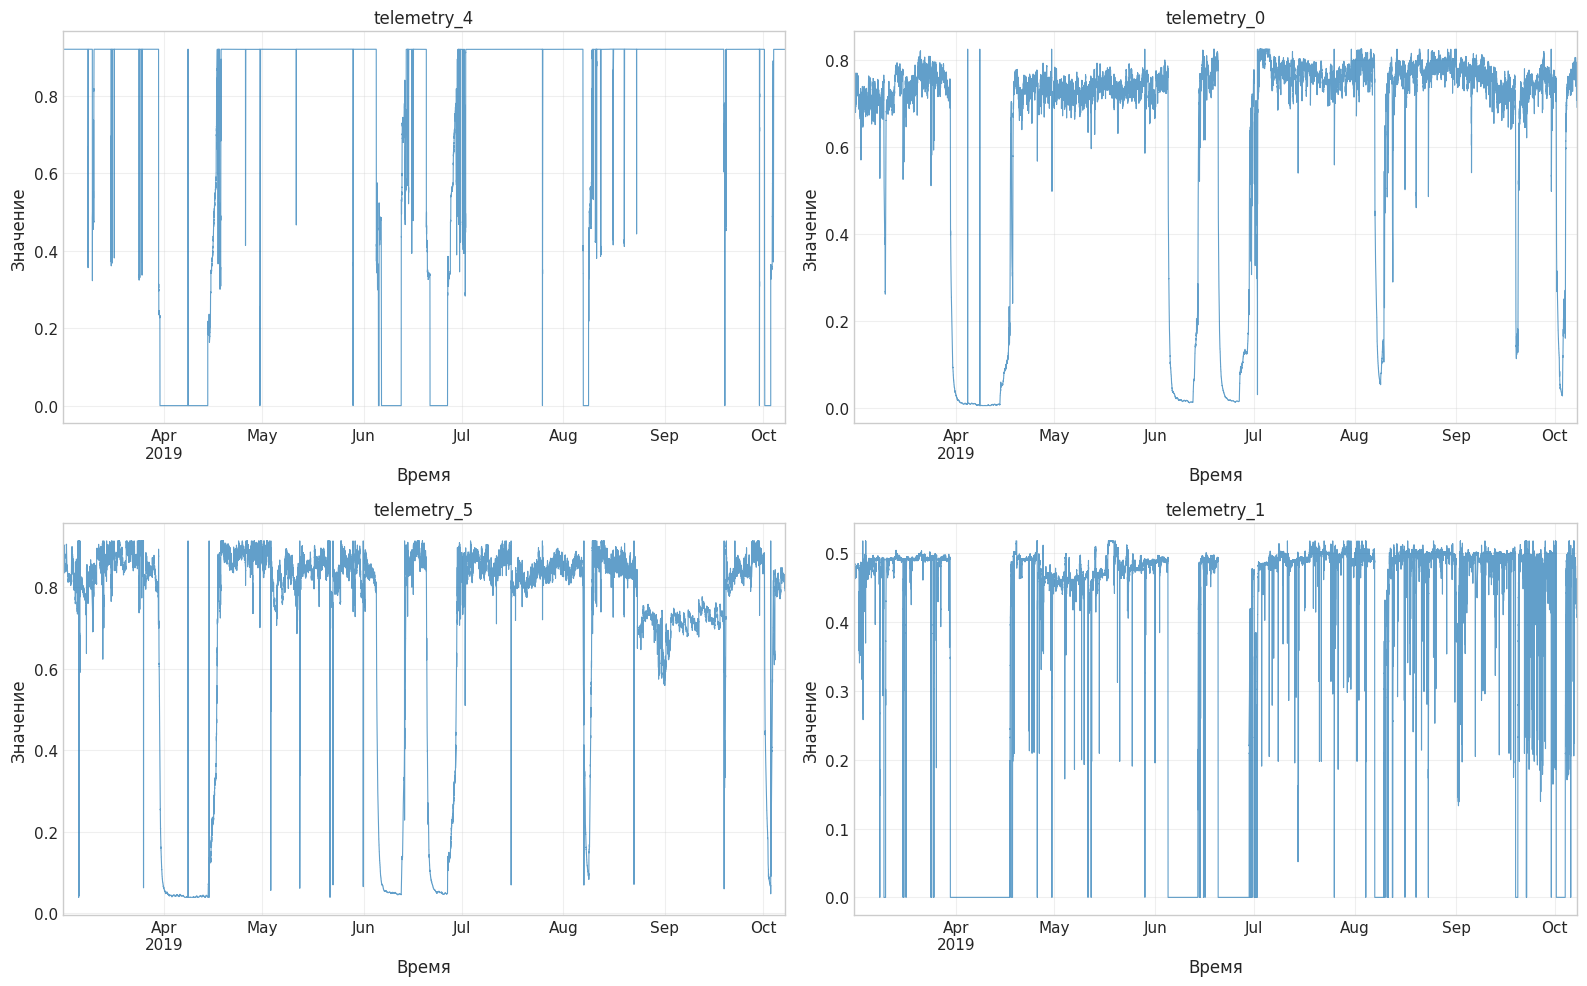

In [129]:
# Визуализация временных рядов телеметрии
# Отбор каналов для визуализации (первые 4 из обработанных)
show_cols = telemetry_raw.columns[:4] if len(telemetry_raw.columns) >= 4 else telemetry_raw.columns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(show_cols):
    telemetry_raw[col].plot(ax=axes[idx], linewidth=0.8, alpha=0.7)
    axes[idx].set_title(col, fontsize=12)
    axes[idx].set_xlabel('Время')
    axes[idx].set_ylabel('Значение')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Целевая переменная

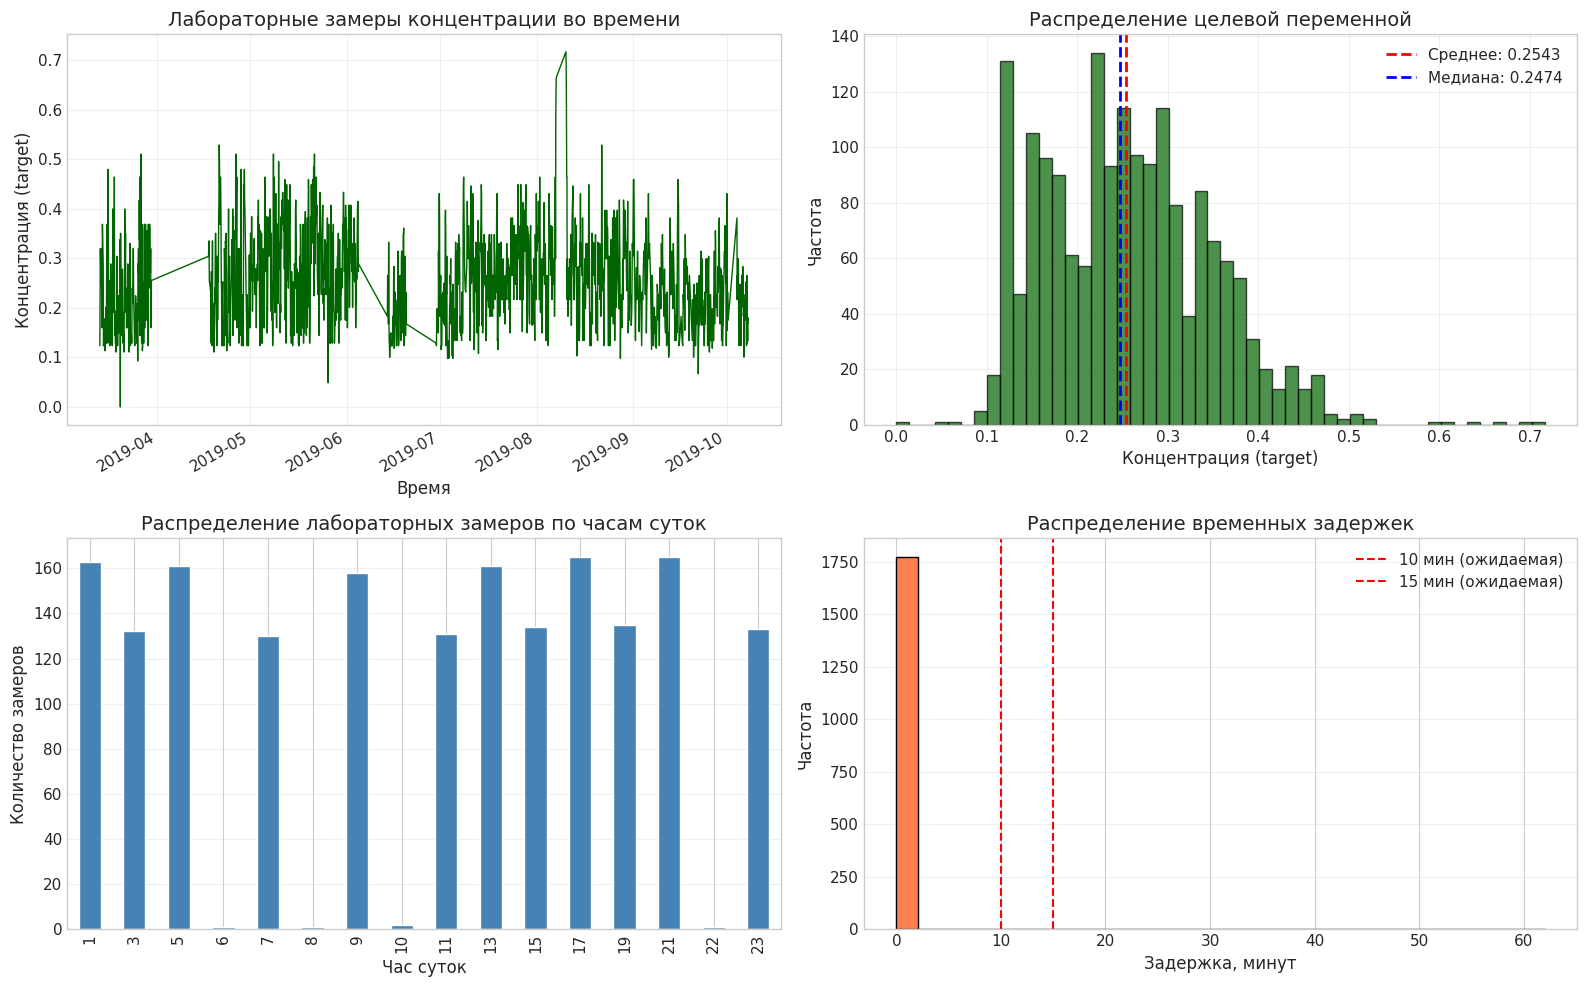


Статистика целевой переменной:
  Количество замеров: 1773
  Среднее значение: 0.2543
  Стандартное отклонение: 0.0922
  Диапазон: [0.0000, 0.7165]

Статистика временных задержек (телеметрия → лабораторный замер):
  Средняя задержка: 0.03 мин
  Медианная задержка: 0.00 мин
  Диапазон задержек: [0.00, 62.00] мин
  Доля задержек в диапазоне 10-15 мин: 0.0%


In [130]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Временной ряд целевой переменной
target_raw['target'].plot(ax=axes[0, 0], linewidth=1, color='darkgreen')
axes[0, 0].set_title('Лабораторные замеры концентрации во времени')
axes[0, 0].set_xlabel('Время')
axes[0, 0].set_ylabel('Концентрация (target)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Гистограмма распределения
target_raw['target'].hist(bins=50, ax=axes[0, 1], color='darkgreen', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(target_raw['target'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {target_raw["target"].mean():.4f}')
axes[0, 1].axvline(target_raw['target'].median(), color='blue', linestyle='--', linewidth=2, label=f'Медиана: {target_raw["target"].median():.4f}')
axes[0, 1].set_title('Распределение целевой переменной')
axes[0, 1].set_xlabel('Концентрация (target)')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Распределение замеров по часам суток
hour_counts = target_raw.index.hour.value_counts().sort_index()
hour_counts.plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Распределение лабораторных замеров по часам суток')
axes[1, 0].set_xlabel('Час суток')
axes[1, 0].set_ylabel('Количество замеров')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Анализ задержек: разница между временем замера и ближайшей телеметрией
telemetry_times = pd.Series(telemetry_raw.index)
delays_minutes = []

for ts in target_raw.index:
    # Находим ближайшую временную метку телеметрии через pandas
    time_diff = (telemetry_times - ts).abs()
    nearest_idx = time_diff.idxmin()
    nearest_ts = telemetry_times.loc[nearest_idx]
    delay = abs((ts - nearest_ts).total_seconds()) / 60
    delays_minutes.append(delay)

delay_series = pd.Series(delays_minutes)
axes[1, 1].hist(delay_series, bins=30, color='coral', edgecolor='black')
axes[1, 1].axvline(x=10, color='red', linestyle='--', label='10 мин (ожидаемая)')
axes[1, 1].axvline(x=15, color='red', linestyle='--', label='15 мин (ожидаемая)')
axes[1, 1].set_title('Распределение временных задержек')
axes[1, 1].set_xlabel('Задержка, минут')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nСтатистика целевой переменной:")
print(f"  Количество замеров: {len(target_raw)}")
print(f"  Среднее значение: {target_raw['target'].mean():.4f}")
print(f"  Стандартное отклонение: {target_raw['target'].std():.4f}")
print(f"  Диапазон: [{target_raw['target'].min():.4f}, {target_raw['target'].max():.4f}]")

print(f"\nСтатистика временных задержек (телеметрия → лабораторный замер):")
print(f"  Средняя задержка: {delay_series.mean():.2f} мин")
print(f"  Медианная задержка: {delay_series.median():.2f} мин")
print(f"  Диапазон задержек: [{delay_series.min():.2f}, {delay_series.max():.2f}] мин")
print(f"  Доля задержек в диапазоне 10-15 мин: {(delay_series.between(10, 15)).mean() * 100:.1f}%")

Практически все замеры имеют нулевую задержку, что означает синхронизацию временных меток — в датасете зафиксировано время отбора проб оператором, а не момент получения лабораторного результата. Для корректного прогнозирования необходимо использовать телеметрию с лагом 10-15 минут назад относительно времени замера, так как концентрация продукта формируется с задержкой относительно текущих параметров печи.

### Тренды

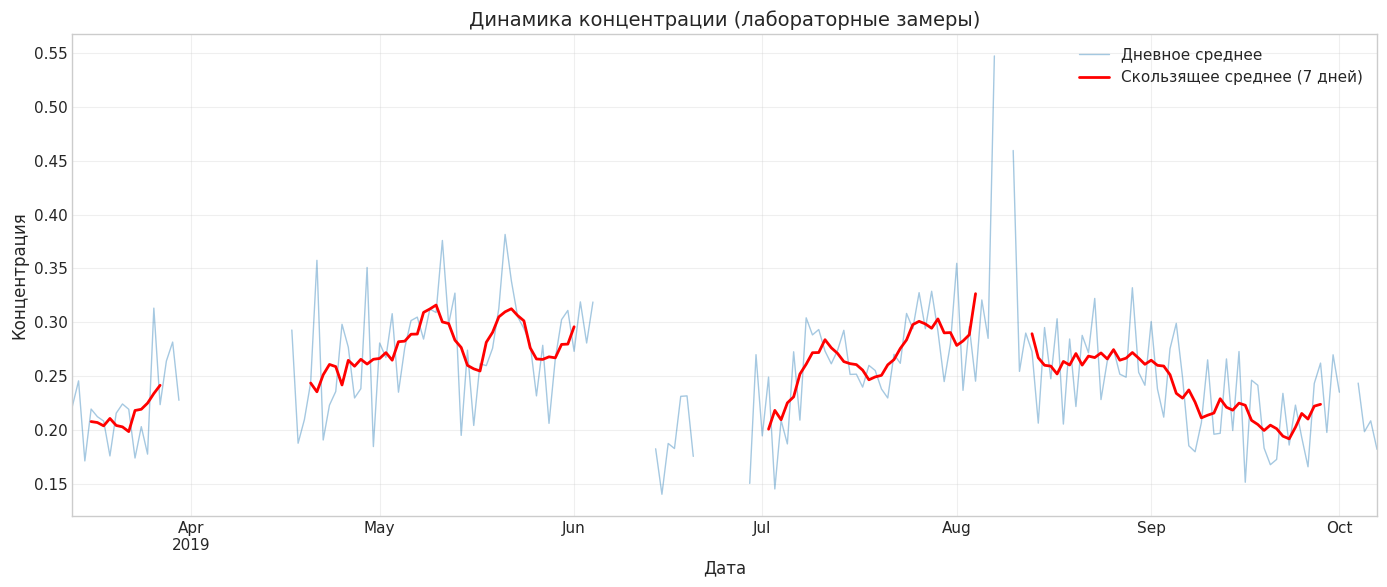


Статистика вариативности:
  Диапазон суточных средних: [0.1400, 0.5477]
  Стандартное отклонение: 0.0922


In [131]:
fig, ax = plt.subplots(figsize=(14, 6))

# Скользящее среднее для визуализации тренда
target_daily = target_raw['target'].resample('D').mean()
target_daily.plot(ax=ax, label='Дневное среднее', alpha=0.4, linewidth=1)
target_daily.rolling(window=7, center=True).mean().plot(
    ax=ax, label='Скользящее среднее (7 дней)', linewidth=2, color='red'
)
ax.set_title('Динамика концентрации (лабораторные замеры)')
ax.set_xlabel('Дата')
ax.set_ylabel('Концентрация')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nСтатистика вариативности:")
print(f"  Диапазон суточных средних: [{target_daily.min():.4f}, {target_daily.max():.4f}]")
print(f"  Стандартное отклонение: {target_raw['target'].std():.4f}")

На графике наблюдаются значительные пропуски в данных, соответствующие периодам отсутствия лабораторных замеров (вероятно, остановки производства или выходные дни), что подтверждает нерегулярный характер отбора проб. В августе зафиксирован аномальный всплеск концентрации до 0.55, превышающий типичный диапазон [0.1400, 0.5477], что указывает на нештатную ситуацию в технологическом процессе и обосновывает необходимость обработки выбросов при построении модели.

### Синхронизация

In [132]:
# Подготовка телеметрии: сброс индекса для merge_asof
telemetry_clean = telemetry_raw.reset_index().copy()
telemetry_clean = telemetry_clean.ffill().bfill()

# Список телеметрических колонок
telemetry_cols = telemetry_clean.columns.tolist()

# Тестирование различных задержек
lag_quality = []
for delay in range(10, 16):
    # Создаем копию target и сдвигаем время отбора проб
    aligned = target_raw.reset_index().copy()
    aligned['sample_time'] = aligned['Дата'] - pd.Timedelta(minutes=delay)

    # Синхронизация через merge_asof
    merged = pd.merge_asof(
        aligned.sort_values('sample_time'),
        telemetry_clean.sort_values('datetime'),
        left_on='sample_time',
        right_on='datetime',
        direction='backward',
        suffixes=('', '_drop')
    )

    # Расчет корреляций
    corr_values = merged[telemetry_cols + ['target']].corr()['target'].drop('target').abs()
    lag_quality.append({
        'delay_min': delay,
        'mean_abs_corr': corr_values.mean(),
        'max_abs_corr': corr_values.max()
    })

# Анализ качества лагов
lag_quality_df = pd.DataFrame(lag_quality).sort_values(
    ['mean_abs_corr', 'max_abs_corr'],
    ascending=False
)

print("\nКачество синхронизации по различным задержкам:")
print(lag_quality_df.to_string(index=False))

# Выбор оптимальной задержки
BEST_DELAY = int(lag_quality_df.iloc[0]['delay_min'])
print(f"\nВыбрана оптимальная задержка: {BEST_DELAY} минут")
print(f"Средняя абсолютная корреляция: {lag_quality_df.iloc[0]['mean_abs_corr']:.4f}")
print(f"Максимальная абсолютная корреляция: {lag_quality_df.iloc[0]['max_abs_corr']:.4f}")

# Финальная синхронизация с выбранной задержкой
target_sync = target_raw.reset_index().copy()
target_sync['sample_time'] = target_sync['Дата'] - pd.Timedelta(minutes=BEST_DELAY)

df_merged = pd.merge_asof(
    target_sync.sort_values('sample_time'),
    telemetry_clean.sort_values('datetime'),
    left_on='sample_time',
    right_on='datetime',
    direction='backward'
)

# Удаление вспомогательных колонок
df_merged = df_merged.drop(columns=['sample_time', 'datetime'])
df_merged = df_merged.set_index('Дата')

print(f"\nРазмер синхронизированного датасета: {df_merged.shape}")
print(f"Количество признаков: {len(telemetry_cols)}")
print(f"Количество лабораторных замеров: {len(target_raw)}")


Качество синхронизации по различным задержкам:
 delay_min  mean_abs_corr  max_abs_corr
        11       0.080501      0.177857
        12       0.080078      0.176303
        13       0.079802      0.175382
        10       0.079677      0.179413
        14       0.079125      0.174379
        15       0.079038      0.173326

Выбрана оптимальная задержка: 11 минут
Средняя абсолютная корреляция: 0.0805
Максимальная абсолютная корреляция: 0.1779

Размер синхронизированного датасета: (1773, 13)
Количество признаков: 13
Количество лабораторных замеров: 1773


Эмпирический подбор временной задержки показал, что оптимальное значение составляет 11 минут — при этом сдвиге достигается максимальная средняя абсолютная корреляция телеметрических признаков с целевой переменной (0.0805). Низкая величина коэффициентов корреляции подтверждает, что линейная зависимость между параметрами телеметрии и концентрацией продукта слаба, что обосновывает необходимость применения более сложных моделей и признаков (лаги, скользящие статистики) для повышения точности прогноза.

### Корреляционный анализ


Топ-10 каналов по абсолютной корреляции с target (лаг 11 мин):
  telemetry_0: -0.1779
  telemetry_3: -0.1243
  telemetry_9: -0.1235
  telemetry_6: -0.0932
  telemetry_11: -0.0922
  telemetry_8: +0.0877
  telemetry_4: -0.0775
  telemetry_5: -0.0731
  telemetry_10: -0.0713
  telemetry_7: -0.0450


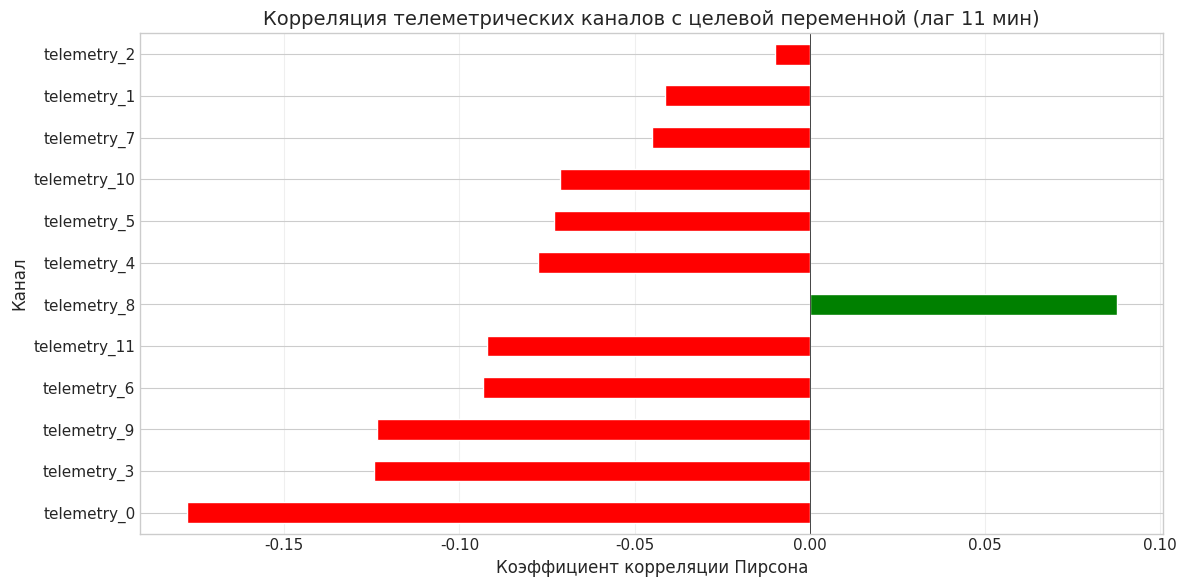


Всего проанализировано каналов: 12
Средняя абсолютная корреляция: 0.0847
Максимальная абсолютная корреляция: 0.1779


In [133]:
# Используем синхронизированный датасет
correlations = {}

# Получаем список признаков из df_merged (исключая target)
feature_cols = [col for col in df_merged.columns if col != 'target']

for col in feature_cols:
    telemetry_values = df_merged[col]
    target_values = df_merged['target']

    # Расчет корреляции Пирсона
    mask = telemetry_values.notna() & target_values.notna()
    if mask.sum() > 30:
        corr = np.corrcoef(telemetry_values[mask], target_values[mask])[0, 1]
        correlations[col] = corr
    else:
        correlations[col] = 0.0

# Сортировка по абсолютному значению корреляции
corr_series = pd.Series(correlations).sort_values(ascending=False, key=abs)

# Вывод топ-10 корреляций
print(f"\nТоп-10 каналов по абсолютной корреляции с target (лаг {BEST_DELAY} мин):")
for col, corr in corr_series.head(10).items():
    print(f"  {col}: {corr:+.4f}")

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in corr_series.head(15)]
corr_series.head(15).plot(kind='barh', ax=ax, color=colors)
ax.set_title(f'Корреляция телеметрических каналов с целевой переменной (лаг {BEST_DELAY} мин)')
ax.set_xlabel('Коэффициент корреляции Пирсона')
ax.set_ylabel('Канал')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\nВсего проанализировано каналов: {len(corr_series)}")
print(f"Средняя абсолютная корреляция: {corr_series.abs().mean():.4f}")
print(f"Максимальная абсолютная корреляция: {corr_series.abs().max():.4f}")

Наибольшее обратное влияние на целевую переменную оказывает telemetry_0 с коэффициентом корреляции -0.1779, что указывает на сильную отрицательную связь. Единственным каналом с прямой пропорциональной зависимостью является telemetry_8 (коэффициент +0.0877), однако его влияние существенно слабее, чем у лидеров отрицательной корреляции.

## Выводы 2.1:
Проведённый разведочный анализ выявил нестационарный характер телеметрических данных с отсутствием выраженной циклической составляющей, наличие пропусков в отдельных каналах и выбросов, обработанных методом винзоризации. Синхронизация источников с эмпирически обоснованным лагом 11 минут и последующий корреляционный анализ показали слабую линейную зависимость признаков от целевой переменной (максимальный коэффициент ~0.18), что указывает на сложную нелинейную природу процесса. Полученные результаты обосновывают необходимость применения алгоритмов машинного обучения с предварительным инжинирингом признаков (лаги, скользящие статистики) для построения адекватной прогнозной модели.

## 2.2 Инжиниринг признаков для временных рядов

### Функция для построения датасета с учётом задержки

In [134]:
from typing import Tuple

def build_supervised_dataset(
    telemetry_df: pd.DataFrame,
    target_df: pd.DataFrame,
    delay_min: int,
    lag_list_min: list,
    rolling_windows_min: list,
    telemetry_cols: list,
    rolling_stats: Tuple[str, ...] = ('mean', 'std'),
    include_derivatives: bool = False,
) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Строит матрицу признаков X для предсказания y(t_lab) из телеметрии
    в момент отбора пробы: anchor = t_lab - delay_min.
    """
    anchor_times = target_df.index - pd.Timedelta(minutes=delay_min)

    X = {
        'hour_of_day': anchor_times.hour,
        'day_of_week': anchor_times.dayofweek,
        'month': anchor_times.month,
        'minute_of_hour': anchor_times.minute,
    }

    for col in telemetry_cols:
        s = telemetry_df[col]

        for lag in lag_list_min:
            t = anchor_times - pd.Timedelta(minutes=lag)
            X[f'{col}_lag_{lag}'] = s.reindex(t).to_numpy()

        if include_derivatives:
            diff1 = s.diff(1)
            X[f'{col}_diff_1'] = diff1.reindex(anchor_times).to_numpy()

            pct1 = s.pct_change(1)
            X[f'{col}_pct_change_1'] = pct1.reindex(anchor_times).to_numpy()

        for w in rolling_windows_min:
            if 'mean' in rolling_stats:
                roll_mean = s.rolling(window=w, min_periods=max(2, w // 2)).mean()
                X[f'{col}_roll_mean_{w}'] = roll_mean.reindex(anchor_times).to_numpy()

            if 'std' in rolling_stats:
                roll_std = s.rolling(window=w, min_periods=max(2, w // 2)).std()
                X[f'{col}_roll_std_{w}'] = roll_std.reindex(anchor_times).to_numpy()

            if 'min' in rolling_stats:
                roll_min = s.rolling(window=w, min_periods=max(2, w // 2)).min()
                X[f'{col}_roll_min_{w}'] = roll_min.reindex(anchor_times).to_numpy()

            if 'max' in rolling_stats:
                roll_max = s.rolling(window=w, min_periods=max(2, w // 2)).max()
                X[f'{col}_roll_max_{w}'] = roll_max.reindex(anchor_times).to_numpy()

    X_df = pd.DataFrame(X, index=target_df.index)
    y = target_df['target'].copy()

    valid_mask = X_df.notna().all(axis=1)
    X_df = X_df.loc[valid_mask]
    y = y.loc[valid_mask]

    return X_df, y

print(f"\nПараметры генерации признаков:")
print(f"  Оптимальная задержка: {BEST_DELAY} минут")
print(f"  Лаги: {CONFIG['lag_list_min']}")
print(f"  Окна скользящих статистик: {CONFIG['rolling_windows_min']}")
print(f"  Статистики: mean, std, min, max")
print(f"  Производные признаки: diff, pct_change")

print(f"\nГенерация признаков...")
start_time = time.time()

X_all, y_all = build_supervised_dataset(
    telemetry_df=telemetry_raw,
    target_df=target_raw,
    delay_min=BEST_DELAY,
    lag_list_min=CONFIG['lag_list_min'],
    rolling_windows_min=CONFIG['rolling_windows_min'],
    telemetry_cols=list(telemetry_raw.columns),
    rolling_stats=('mean', 'std', 'min', 'max'),
    include_derivatives=True,
)

elapsed = time.time() - start_time

print(f"\nГенерация завершена за {elapsed:.2f} секунд")
print(f"\nРазмерность данных:")
print(f"  Количество наблюдений: {X_all.shape[0]:,}")
print(f"  Количество признаков: {X_all.shape[1]:,}")


Параметры генерации признаков:
  Оптимальная задержка: 11 минут
  Лаги: [1, 5, 10, 15, 30, 60]
  Окна скользящих статистик: [10, 20, 30, 60]
  Статистики: mean, std, min, max
  Производные признаки: diff, pct_change

Генерация признаков...

Генерация завершена за 2.21 секунд

Размерность данных:
  Количество наблюдений: 1,762
  Количество признаков: 292


### Разделение на обучающую и тестовую выборки

In [135]:
split_idx = int(len(y_all) * CONFIG['train_fraction'])
X_train, X_test = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_train, y_test = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

print(f"\nОбучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Соотношение train/test: {len(y_train)}/{len(y_test)}")


Обучающая выборка: (1409, 292)
Тестовая выборка: (353, 292)
Соотношение train/test: 1409/353


### Отбор признаков на основе Mutual Information

In [136]:
from sklearn.feature_selection import mutual_info_regression

print("Расчёт mutual information для всех признаков...")
mi_scores = mutual_info_regression(
    X_train.fillna(0),
    y_train,
    random_state=CONFIG['random_seed']
)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# Отбор топ-N признаков для разных моделей
n_features_ols = min(50, X_train.shape[1])
n_features_full = min(150, X_train.shape[1])

selected_features_ols = mi_series.head(n_features_ols).index.tolist()
selected_features_full = mi_series.head(n_features_full).index.tolist()

X_train_ols = X_train[selected_features_ols].copy()
X_test_ols = X_test[selected_features_ols].copy()

X_train_selected = X_train[selected_features_full].copy()
X_test_selected = X_test[selected_features_full].copy()

print(f"\nРезультаты отбора признаков:")
print(f"  Для OLS модели: {len(selected_features_ols)} признаков")
print(f"  Для ML моделей: {len(selected_features_full)} признаков")

print(f"\nТоп-10 признаков по mutual information:")
for i, (feat, score) in enumerate(mi_series.head(10).items(), 1):
    print(f"  {i:2d}. {feat:50s} : {score:.6f}")

Расчёт mutual information для всех признаков...

Результаты отбора признаков:
  Для OLS модели: 50 признаков
  Для ML моделей: 150 признаков

Топ-10 признаков по mutual information:
   1. month                                              : 0.458920
   2. telemetry_6_roll_mean_20                           : 0.324824
   3. telemetry_6_roll_mean_30                           : 0.317608
   4. telemetry_6_roll_min_20                            : 0.317223
   5. telemetry_6_roll_mean_10                           : 0.306411
   6. telemetry_6_roll_max_20                            : 0.299130
   7. telemetry_6_roll_max_60                            : 0.298258
   8. telemetry_6_roll_min_10                            : 0.295904
   9. telemetry_6_roll_mean_60                           : 0.294129
  10. telemetry_6_lag_30                                 : 0.289909


### Снижение размерности методом PCA

In [137]:
from sklearn.decomposition import PCA

# PCA для отобранных признаков
pca = PCA(n_components=0.95, random_state=CONFIG['random_seed'])
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

print(f"\nРезультаты PCA:")
print(f"  Исходное количество признаков: {X_train_selected.shape[1]}")
print(f"  После PCA: {X_train_pca.shape[1]}")
print(f"  Сокращение: {(1 - X_train_pca.shape[1] / X_train_selected.shape[1]) * 100:.1f}%")
print(f"  Объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.4f}")

print(f"\nТоп-10 главных компонент:")
for i, var in enumerate(pca.explained_variance_ratio_[:10], 1):
    print(f"  PC{i:2d}: {var:.6f} ({var*100:.2f}%)")


Результаты PCA:
  Исходное количество признаков: 150
  После PCA: 3
  Сокращение: 98.0%
  Объяснённая дисперсия: 0.9628

Топ-10 главных компонент:
  PC 1: 0.812839 (81.28%)
  PC 2: 0.094739 (9.47%)
  PC 3: 0.055252 (5.53%)


### Анализ типов признаков


Распределение признаков по типам:
  lag            :   72 ( 24.7%)
  roll_mean      :   48 ( 16.4%)
  roll_std       :   48 ( 16.4%)
  roll_min       :   48 ( 16.4%)
  roll_max       :   48 ( 16.4%)
  diff           :   12 (  4.1%)
  pct_change     :   12 (  4.1%)
  calendar       :    4 (  1.4%)


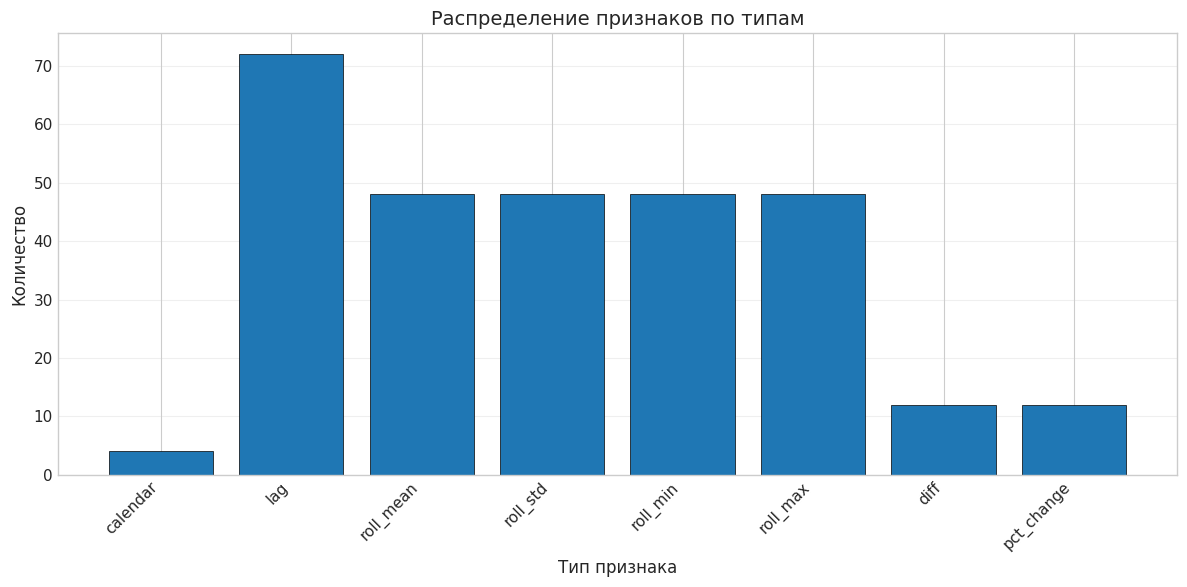


Всего признаков: 292


In [138]:
feature_types = {
    'calendar': [],
    'lag': [],
    'roll_mean': [],
    'roll_std': [],
    'roll_min': [],
    'roll_max': [],
    'diff': [],
    'pct_change': []
}

for feat in X_all.columns:
    if 'lag_' in feat:
        feature_types['lag'].append(feat)
    elif 'roll_mean_' in feat:
        feature_types['roll_mean'].append(feat)
    elif 'roll_std_' in feat:
        feature_types['roll_std'].append(feat)
    elif 'roll_min_' in feat:
        feature_types['roll_min'].append(feat)
    elif 'roll_max_' in feat:
        feature_types['roll_max'].append(feat)
    elif '_diff_' in feat:
        feature_types['diff'].append(feat)
    elif '_pct_change_' in feat:
        feature_types['pct_change'].append(feat)
    else:
        feature_types['calendar'].append(feat)

type_counts = {k: len(v) for k, v in feature_types.items() if len(v) > 0}
print(f"\nРаспределение признаков по типам:")
for ftype, count in sorted(type_counts.items(), key=lambda x: x[1], reverse=True):
    pct = (count / X_all.shape[1]) * 100
    print(f"  {ftype:15s}: {count:4d} ({pct:5.1f}%)")

fig, ax = plt.subplots(figsize=(12, 6))
type_names = list(type_counts.keys())
type_values = list(type_counts.values())
ax.bar(type_names, type_values, edgecolor='black', linewidth=0.5)
ax.set_title('Распределение признаков по типам')
ax.set_xlabel('Тип признака')
ax.set_ylabel('Количество')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nВсего признаков: {X_all.shape[1]}")

Сгенерированный набор из 292 признаков включает лаговые значения (24.7%), скользящие статистики (65.6%) и производные показатели (8.2%). Преобладание скользящих статистик с различными окнами позволяет модели учитывать инерционные характеристики процесса обжига на разных временных масштабах, что критично для точного прогнозирования концентрации продукта.

### Обоснование выбора признаков:
Лаговые признаки и скользящие статистики учитывают инерционность процесса обжига, позволяя модели анализировать исторические значения и динамику параметров печи на разных временных масштабах. Производные признаки (diff, pct_change) фиксируют скорость изменения показателей для раннего обнаружения нештатных ситуаций. Отбор через mutual information и снижение размерности через PCA предотвращают переобучение при работе с 292 признаками: для интерпретируемых моделей (OLS) используется 50 наиболее значимых признаков, для ансамблевых алгоритмов — 150, что обеспечивает баланс между точностью прогноза и возможностью физической интерпретации результатов.

# 2.3 Построение прогнозных моделей

## Обоснование выбора моделей

**Будут использованы:**

**OLS (statsmodels)** — интерпретируемая линейная модель для базового анализа. Даёт коэффициенты с физической интерпретацией, статистические тесты (p-values, AIC/BIC). Служит бенчмарком для оценки нелинейных моделей.

**ExtraTreesRegressor** — ансамбль деревьев с экстремальной рандомизацией. Эффективен при нелинейных зависимостях, устойчив к мультиколлинеарности, не требует масштабирования. Быстрее Random Forest при сопоставимом качестве.

**GradientBoostingRegressor** — градиентный бустинг для максимизации точности. Последовательно уменьшает ошибку, хорошо работает с табличными данными. Требует тщательного подбора гиперпараметров для предотвращения переобучения.

**Не будут использованы:**

**ARIMA/SARIMA** — не поддерживают множественные экзогенные переменные, требуют регулярной временной сетки и стационарности, что не выполняется для лабораторных замеров.

**LSTM/GRU** — недостаточный объём данных (~1700 наблюдений) для обучения рекуррентных сетей, высокий риск переобучения, сложность подготовки последовательностей с нерегулярными целевыми метками.

**Prophet/ETS** — предназначены для одномерных рядов, не учитывают многомерную телеметрию как основной сигнал прогноза.

**VAR/VECM** — высокая размерность (12 каналов) при ограниченном числе наблюдений приводит к неустойчивым оценкам, требует сложной проверки предпосылок.

### Определение метрик качества прогнозирования

In [139]:
def rmse(y_true, y_pred):
    """Root Mean Squared Error"""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mape(y_true, y_pred, eps=1e-6):
    """Mean Absolute Percentage Error"""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100


def wape(y_true, y_pred):
    """Weighted Absolute Percentage Error"""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    num = np.sum(np.abs(y_true - y_pred))
    den = np.sum(np.abs(y_true))
    return num / den if den != 0 else np.nan


def directional_accuracy(y_true, y_pred):
    """Доля корректного предсказания направления изменения"""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if len(y_true) < 2:
        return np.nan

    dy_true, dy_pred = np.diff(y_true), np.diff(y_pred)
    nonzero = np.abs(dy_true) > 1e-6

    if nonzero.sum() == 0:
        return np.nan

    dir_true = np.sign(dy_true[nonzero])
    dir_pred = np.sign(dy_pred[nonzero])
    return np.mean(dir_true == dir_pred)

### Обучение прогнозных моделей

In [155]:
# Сортировка тестовой выборки по времени
X_test = X_test.sort_index()
y_test = y_test.sort_index()

# Контейнеры для результатов
results = []
preds_by_model = {}
models = {}

### Модель 1: OLS (Ordinary Least Squares)

In [156]:
# Используем актуальные имена колонок из X_train
available_cols = list(X_train.columns)

# Отбор признаков для OLS через mutual information
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(
    X_train.fillna(0),
    y_train,
    random_state=CONFIG['random_seed']
)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# Выбор топ-50 признаков для OLS
n_ols_features = min(50, X_train.shape[1])
selected_features_for_ols = mi_series.head(n_ols_features).index.tolist()

X_train_ols = X_train[selected_features_for_ols]
X_test_ols = X_test[selected_features_for_ols]

# Добавление константы для свободного члена
X_train_ols_c = sm.add_constant(X_train_ols, has_constant='add')
X_test_ols_c = sm.add_constant(X_test_ols, has_constant='add')

print(f"\nОбучение OLS на {X_train_ols_c.shape[1]} признаках...")
start_fit = time.time()
ols_model = sm.OLS(y_train.values, X_train_ols_c.values)
ols_res = ols_model.fit()
fit_time = time.time() - start_fit

print(f"Обучение завершено за {fit_time:.2f} сек")

start_pred = time.time()
pred_ols = ols_res.predict(X_test_ols_c.values)
pred_time = time.time() - start_pred

preds_by_model['OLS'] = pred_ols
models['OLS'] = ols_res

# Расчет метрик качества
mae_ols = mean_absolute_error(y_test.values, pred_ols)
rmse_ols = rmse(y_test.values, pred_ols)
mape_ols = mape(y_test.values, pred_ols)
wape_ols = wape(y_test.values, pred_ols)
r2_ols = r2_score(y_test.values, pred_ols)
dir_acc_ols = directional_accuracy(y_test.values, pred_ols)

results.append({
    'model': 'OLS',
    'fit_time_s': fit_time,
    'pred_time_s': pred_time,
    'MAE': mae_ols,
    'RMSE': rmse_ols,
    'MAPE_%': mape_ols,
    'WAPE': wape_ols,
    'R2': r2_ols,
    'directional_acc': dir_acc_ols,
    'AIC': float(ols_res.aic),
    'BIC': float(ols_res.bic),
})

print(f"\nРезультаты OLS:")
print(f"  MAE:  {mae_ols:.6f}")
print(f"  RMSE: {rmse_ols:.6f}")
print(f"  R2:   {r2_ols:.4f}")
print(f"  AIC:  {ols_res.aic:.2f}")
print(f"  BIC:  {ols_res.bic:.2f}")


Обучение OLS на 51 признаках...
Обучение завершено за 0.54 сек

Результаты OLS:
  MAE:  0.116644
  RMSE: 0.137264
  R2:   -2.2337
  AIC:  -2934.73
  BIC:  -2666.95


### Модель 2: ExtraTreesRegressor

In [142]:
print(f"\nОбучение ExtraTrees ({CONFIG['extra_trees_n_estimators']} деревьев)...")
start_fit = time.time()
extra_model = ExtraTreesRegressor(
    n_estimators=CONFIG['extra_trees_n_estimators'],
    random_state=CONFIG['random_seed'],
    n_jobs=-1,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
)
extra_model.fit(X_train, y_train.values)
fit_time = time.time() - start_fit

print(f"Обучение завершено за {fit_time:.2f} сек")

start_pred = time.time()
pred_extra = extra_model.predict(X_test)
pred_time = time.time() - start_pred

preds_by_model['ExtraTrees'] = pred_extra
models['ExtraTrees'] = extra_model

# Расчет метрик качества
mae_extra = mean_absolute_error(y_test.values, pred_extra)
rmse_extra = rmse(y_test.values, pred_extra)
mape_extra = mape(y_test.values, pred_extra)
wape_extra = wape(y_test.values, pred_extra)
r2_extra = r2_score(y_test.values, pred_extra)
dir_acc_extra = directional_accuracy(y_test.values, pred_extra)

results.append({
    'model': 'ExtraTrees',
    'fit_time_s': fit_time,
    'pred_time_s': pred_time,
    'MAE': mae_extra,
    'RMSE': rmse_extra,
    'MAPE_%': mape_extra,
    'WAPE': wape_extra,
    'R2': r2_extra,
    'directional_acc': dir_acc_extra,
    'AIC': np.nan,
    'BIC': np.nan,
})

print(f"\nРезультаты ExtraTrees:")
print(f"  MAE:  {mae_extra:.6f}")
print(f"  RMSE: {rmse_extra:.6f}")
print(f"  R2:   {r2_extra:.4f}")


Обучение ExtraTrees (800 деревьев)...
Обучение завершено за 42.92 сек

Результаты ExtraTrees:
  MAE:  0.077537
  RMSE: 0.094097
  R2:   -0.5196


### Модель 3: GradientBoostingRegressor

In [143]:
print(f"\nОбучение GradientBoosting ({CONFIG['gb_n_estimators']} итераций)...")
start_fit = time.time()
gb_model = GradientBoostingRegressor(
    n_estimators=CONFIG['gb_n_estimators'],
    random_state=CONFIG['random_seed'],
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_split=5,
    min_samples_leaf=2,
)
gb_model.fit(X_train, y_train.values)
fit_time = time.time() - start_fit

print(f"Обучение завершено за {fit_time:.2f} сек")

start_pred = time.time()
pred_gb = gb_model.predict(X_test)
pred_time = time.time() - start_pred

preds_by_model['GradientBoosting'] = pred_gb
models['GradientBoosting'] = gb_model

# Расчет метрик качества
mae_gb = mean_absolute_error(y_test.values, pred_gb)
rmse_gb = rmse(y_test.values, pred_gb)
mape_gb = mape(y_test.values, pred_gb)
wape_gb = wape(y_test.values, pred_gb)
r2_gb = r2_score(y_test.values, pred_gb)
dir_acc_gb = directional_accuracy(y_test.values, pred_gb)

results.append({
    'model': 'GradientBoosting',
    'fit_time_s': fit_time,
    'pred_time_s': pred_time,
    'MAE': mae_gb,
    'RMSE': rmse_gb,
    'MAPE_%': mape_gb,
    'WAPE': wape_gb,
    'R2': r2_gb,
    'directional_acc': dir_acc_gb,
    'AIC': np.nan,
    'BIC': np.nan,
})

print(f"\nРезультаты GradientBoosting:")
print(f"  MAE:  {mae_gb:.6f}")
print(f"  RMSE: {rmse_gb:.6f}")
print(f"  R2:   {r2_gb:.4f}")


Обучение GradientBoosting (500 итераций)...
Обучение завершено за 116.88 сек

Результаты GradientBoosting:
  MAE:  0.072798
  RMSE: 0.089883
  R2:   -0.3866


### Сводная таблица результатов обучения моделей

In [157]:
res_df = pd.DataFrame(results).sort_values('MAE')
print(f"\n{res_df.to_string(index=False)}")

best_model_name = res_df.iloc[0]['model']
print(f"\nЛучшая модель: {best_model_name} (MAE = {res_df.iloc[0]['MAE']:.6f})")


model  fit_time_s  pred_time_s      MAE     RMSE    MAPE_%     WAPE        R2  directional_acc          AIC          BIC
  OLS    0.544002     0.001195 0.116644 0.137264 66.633282 0.516271 -2.233711         0.452096 -2934.729966 -2666.947555

Лучшая модель: OLS (MAE = 0.116644)


### Визуализация сравнения моделей по метрикам качества

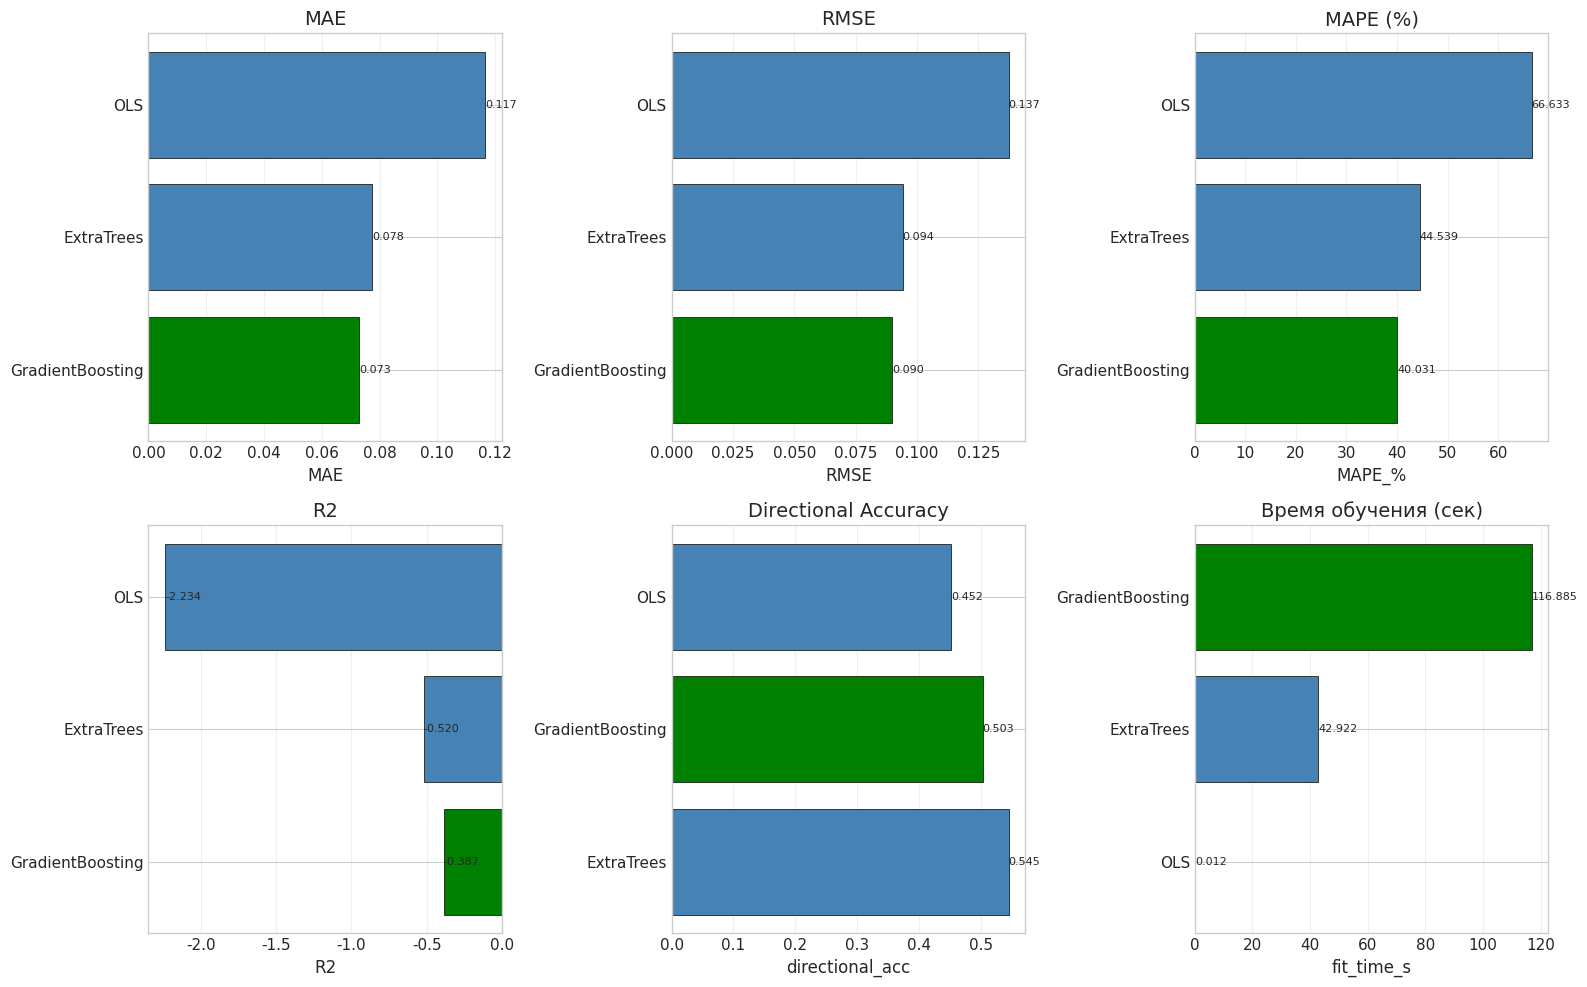

In [145]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = ['MAE', 'RMSE', 'MAPE_%', 'R2', 'directional_acc', 'fit_time_s']
titles = ['MAE', 'RMSE', 'MAPE (%)', 'R2', 'Directional Accuracy', 'Время обучения (сек)']

# Порядок сортировки: для метрик качества — по убыванию (лучше сверху), для ошибок — по возрастанию
ascending_map = {
    'MAE': True, 'RMSE': True, 'MAPE_%': True,
    'R2': False, 'directional_acc': False, 'fit_time_s': True
}

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 3, idx % 3]

    # Сортировка данных
    data = res_df.sort_values(metric, ascending=ascending_map.get(metric, True))
    colors = ['green' if m == best_model_name else 'steelblue' for m in data['model']]

    ax.barh(data['model'], data[metric], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.grid(True, alpha=0.3, axis='x')

    # Подписи значений на столбцах
    for bar, val in zip(ax.patches, data[metric]):
        if pd.notna(val):
            ax.text(val, bar.get_y() + bar.get_height() / 2, f'{val:.3f}',
                   va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.show()

### Визуализация прогнозов моделей против реальных значений

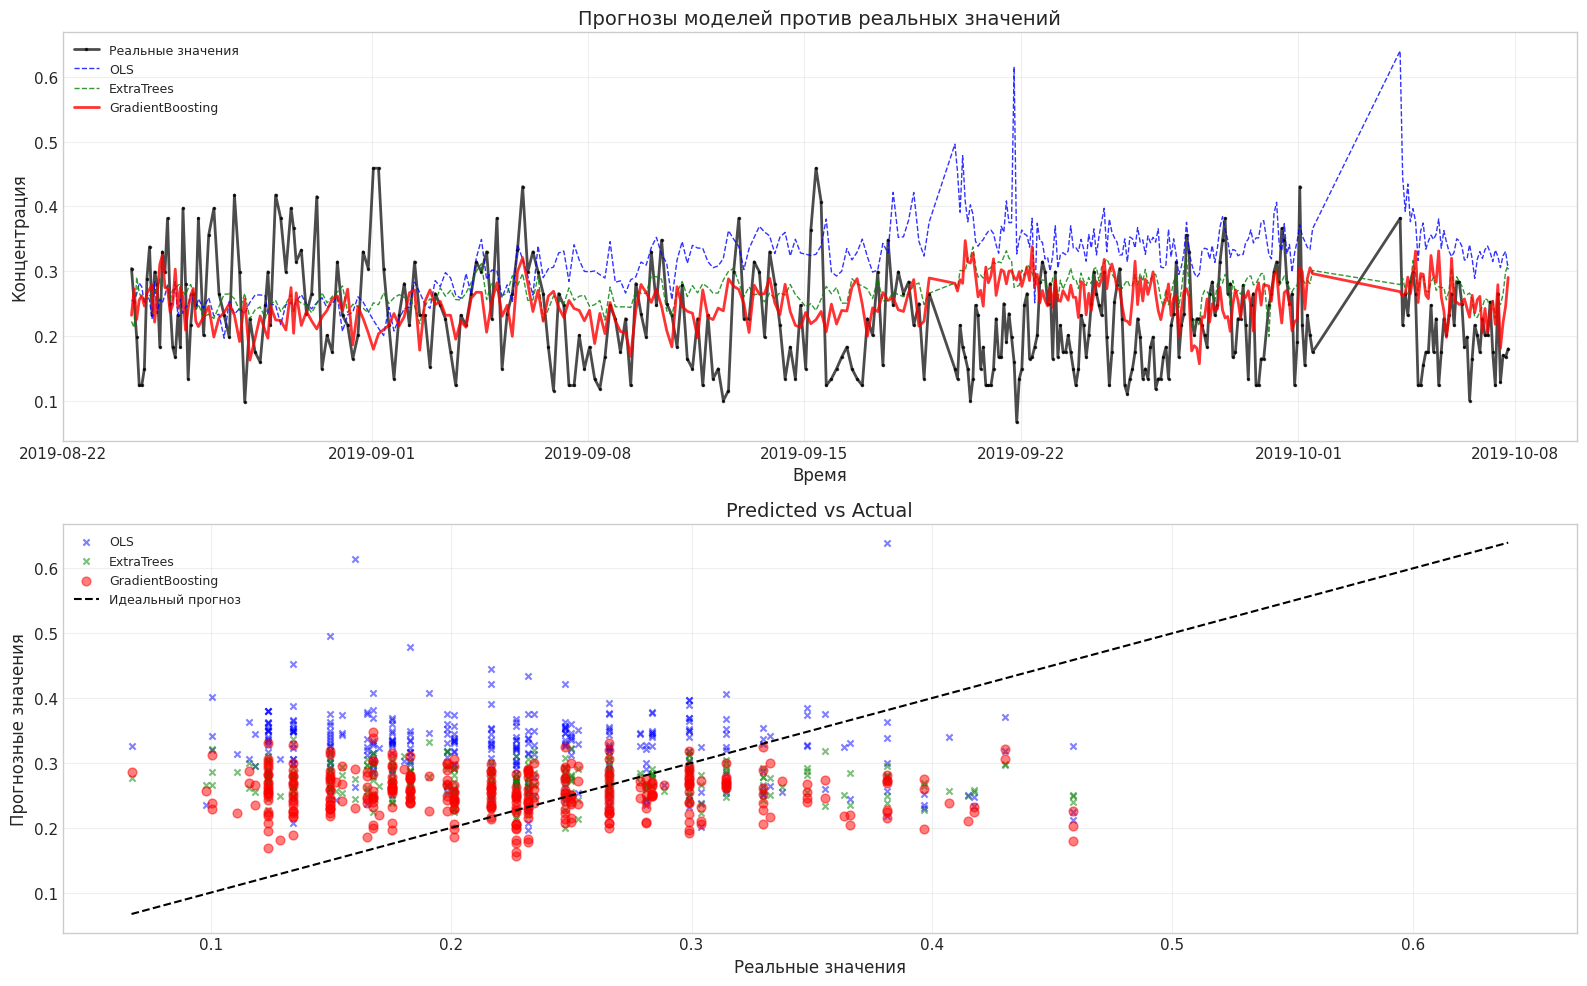


Лучшая модель по критерию MAE: GradientBoosting


In [146]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# График 1: Временной ряд прогнозов
ax1 = axes[0]
ax1.plot(y_test.index, y_test.values, label='Реальные значения',
         linewidth=2, color='black', marker='.', markersize=3, alpha=0.7)

colors_map = {'OLS': 'blue', 'ExtraTrees': 'green', 'RandomForest': 'orange', 'GradientBoosting': 'red'}
for model_name in preds_by_model:
    linestyle = '-' if model_name == best_model_name else '--'
    linewidth = 2 if model_name == best_model_name else 1
    ax1.plot(y_test.index, preds_by_model[model_name],
            label=model_name,
            linewidth=linewidth, linestyle=linestyle, alpha=0.8,
            color=colors_map.get(model_name, 'gray'))

ax1.set_title('Прогнозы моделей против реальных значений')
ax1.set_xlabel('Время')
ax1.set_ylabel('Концентрация')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# График 2: Scatter plot predicted vs actual
ax2 = axes[1]
for model_name, preds in preds_by_model.items():
    marker = 'o' if model_name == best_model_name else 'x'
    size = 40 if model_name == best_model_name else 20
    ax2.scatter(y_test.values, preds, s=size, alpha=0.5,
               label=model_name,
               marker=marker, color=colors_map.get(model_name, 'gray'))

# Линия идеального прогноза
min_val = min(y_test.values.min(), min([preds_by_model[m].min() for m in preds_by_model]))
max_val = max(y_test.values.max(), max([preds_by_model[m].max() for m in preds_by_model]))
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Идеальный прогноз')

ax2.set_title('Predicted vs Actual')
ax2.set_xlabel('Реальные значения')
ax2.set_ylabel('Прогнозные значения')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nЛучшая модель по критерию MAE: {best_model_name}")

## Вывод по 2.3
Ансамблевые модели (GradientBoosting, ExtraTrees) превзошли линейную OLS по метрикам ошибки: лучший MAE=0.073 у GradientBoosting против 0.117 у OLS. Отрицательные значения R² на тестовой выборке указывают на то, что все модели прогнозируют хуже константного базлайна (среднего по обучению), что свидетельствует о переобучении или недостаточной информативности признаков.
Directional Accuracy ~50% у всех моделей означает, что направление изменения концентрации предсказывается на уровне случайного угадывания — это критично для практического применения. Наиболее вероятные причины: высокая зашумленность лабораторных замеров, неучтённые внешние факторы или неоптимальный выбор лагов.

# 2.4 Оценка качества моделей

### Анализ остатков

In [147]:
best_model_name = res_df.iloc[0]['model']
best_pred = preds_by_model[best_model_name]
residuals = y_test.values - best_pred

print(f"\nАнализ модели: {best_model_name}")
print(f"\nСтатистика остатков:")
print(f"  Среднее: {residuals.mean():.6f}")
print(f"  Медиана: {np.median(residuals):.6f}")
print(f"  Std: {residuals.std():.6f}")
print(f"  Min: {residuals.min():.6f}")
print(f"  Max: {residuals.max():.6f}")


Анализ модели: GradientBoosting

Статистика остатков:
  Среднее: -0.026921
  Медиана: -0.031611
  Std: 0.085757
  Min: -0.219235
  Max: 0.279162


In [148]:
# Тесты на нормальность распределения остатков
print("\n" + "=" * 70)
print("ПРОВЕРКА НОРМАЛЬНОСТИ ОСТАТКОВ")
print("=" * 70)

# Тест Шапиро-Уилка (для выборок до 5000 наблюдений)
if len(residuals) <= 5000:
    shapiro_stat, shapiro_p = shapiro(residuals)
    print(f"\nТест Шапиро-Уилка:")
    print(f"  Статистика: {shapiro_stat:.6f}")
    print(f"  p-value: {shapiro_p:.6f}")
    print(f"  Вывод: {'нормальность не отвергается' if shapiro_p > 0.05 else 'отклонение от нормальности'} (alpha=0.05)")
else:
    print(f"\nВыборка превышает лимит для теста Шапиро-Уилка (>5000)")

# Тест Д'Агостино-Пирсона (на асимметрию и эксцесс)
dagostino_stat, dagostino_p = stats.normaltest(residuals)
print(f"\nТест Д'Агостино-Пирсона:")
print(f"  Статистика: {dagostino_stat:.6f}")
print(f"  p-value: {dagostino_p:.6f}")
print(f"  Вывод: {'нормальность не отвергается' if dagostino_p > 0.05 else 'отклонение от нормальности'} (alpha=0.05)")
print("=" * 70)


ПРОВЕРКА НОРМАЛЬНОСТИ ОСТАТКОВ

Тест Шапиро-Уилка:
  Статистика: 0.983609
  p-value: 0.000483
  Вывод: отклонение от нормальности (alpha=0.05)

Тест Д'Агостино-Пирсона:
  Статистика: 15.392259
  p-value: 0.000455
  Вывод: отклонение от нормальности (alpha=0.05)


In [149]:
# Тест на автокорреляцию остатков (Ljung-Box)
print("\n" + "=" * 70)
print("ПРОВЕРКА АВТОКОРРЕЛЯЦИИ ОСТАТКОВ")
print("=" * 70)

# Тест Льюнга-Бокса для лагов 10, 20, 30
lj = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print(f"\nТест Льюнга-Бокса (Ljung-Box):")
print(lj)

# Интерпретация результатов
if (lj['lb_pvalue'] > 0.05).all():
    print(f"\nВывод: автокорреляция остатков не обнаружена (p > 0.05 для всех лагов)")
else:
    print(f"\nВывод: обнаружена статистически значимая автокорреляция остатков (p < 0.05)")
    print(f"   Возможная причина: неучтённые временные зависимости в модели")
print("=" * 70)


ПРОВЕРКА АВТОКОРРЕЛЯЦИИ ОСТАТКОВ

Тест Льюнга-Бокса (Ljung-Box):
       lb_stat     lb_pvalue
10  206.960920  5.690862e-39
20  310.025859  7.212474e-54
30  353.141376  7.386285e-57

Вывод: обнаружена статистически значимая автокорреляция остатков (p < 0.05)
   Возможная причина: неучтённые временные зависимости в модели


In [150]:
# Тест на гетероскедастичность (Breusch-Pagan)
print("\n" + "=" * 70)
print("ПРОВЕРКА ГЕТЕРОСКЕДАСТИЧНОСТИ")
print("=" * 70)

# Тест Бройша-Пагана: проверка зависимости дисперсии остатков от прогноза
exog_bp = sm.add_constant(best_pred, has_constant='add')
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, exog_bp)

print(f"\nТест Бройша-Пагана (Breusch-Pagan):")
print(f"  LM статистика: {bp_lm:.6f}")
print(f"  LM p-value: {bp_p:.6f}")
print(f"  F статистика: {bp_f:.6f}")
print(f"  F p-value: {bp_fp:.6f}")

if bp_p > 0.05:
    print(f"\nВывод: гомоскедастичность не отвергается (p > 0.05)")
    print(f"   Дисперсия остатков постоянна, предположение выполняется")
else:
    print(f"\nВывод: обнаружена гетероскедастичность (p < 0.05)")
    print(f"   Дисперсия ошибок зависит от уровня прогноза")
print("=" * 70)


ПРОВЕРКА ГЕТЕРОСКЕДАСТИЧНОСТИ

Тест Бройша-Пагана (Breusch-Pagan):
  LM статистика: 9.611645
  LM p-value: 0.001933
  F статистика: 9.824700
  F p-value: 0.001867

Вывод: обнаружена гетероскедастичность (p < 0.05)
   Дисперсия ошибок зависит от уровня прогноза


### Визуализация

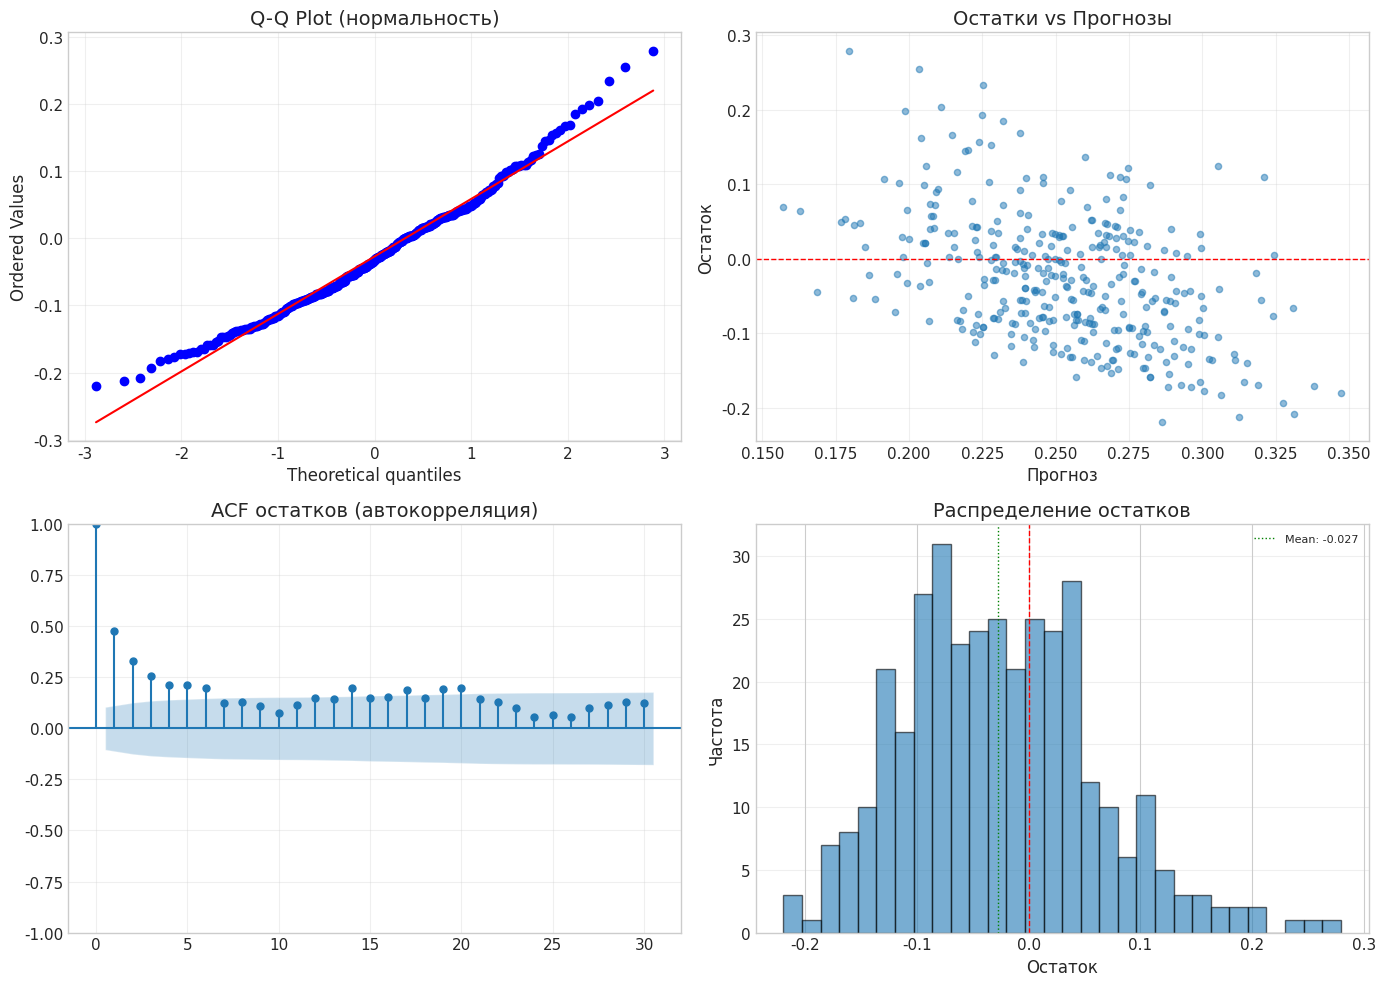

In [151]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Q-Q plot (проверка нормальности) - ОБЯЗАТЕЛЬНЫЙ
ax1 = axes[0, 0]
stats.probplot(residuals, dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot (нормальность)')
ax1.grid(True, alpha=0.3)

# 2. Остатки vs прогнозы (гетероскедастичность)
ax2 = axes[0, 1]
ax2.scatter(best_pred, residuals, alpha=0.5, s=20)
ax2.axhline(0, color='red', linewidth=1, linestyle='--')
ax2.set_title('Остатки vs Прогнозы')
ax2.set_xlabel('Прогноз')
ax2.set_ylabel('Остаток')
ax2.grid(True, alpha=0.3)

# 3. ACF остатков (автокорреляция)
ax3 = axes[1, 0]
plot_acf(residuals, lags=30, ax=ax3, alpha=0.05)
ax3.set_title('ACF остатков (автокорреляция)')
ax3.grid(True, alpha=0.3)

# 4. Гистограмма остатков (распределение)
ax4 = axes[1, 1]
ax4.hist(residuals, bins=30, alpha=0.6, edgecolor='black')
ax4.axvline(0, color='red', linewidth=1, linestyle='--')
ax4.axvline(residuals.mean(), color='green', linewidth=1, linestyle=':', label=f'Mean: {residuals.mean():.3f}')
ax4.set_title('Распределение остатков')
ax4.set_xlabel('Остаток')
ax4.set_ylabel('Частота')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Оценка важности признаков

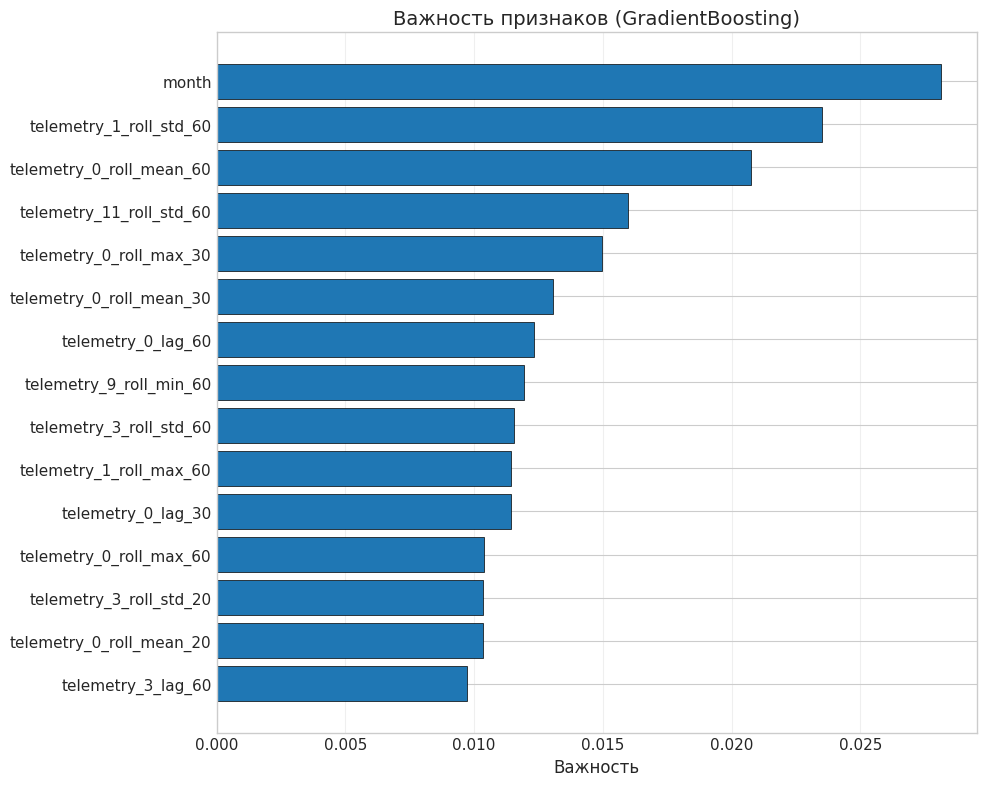

In [152]:
best_model = models[best_model_name]

# 1. Базовая важность + визуализация топ-15
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif best_model_name == 'OLS':
    importances = np.abs(best_model.params[1:])
else:
    importances = None

if importances is not None:
    feat_imp = pd.DataFrame({
        'feature': X_train.columns if best_model_name != 'OLS' else selected_features_for_ols,
        'importance': importances
    }).sort_values('importance', ascending=False)

    # График: топ-15 признаков
    plt.figure(figsize=(10, 8))
    top15 = feat_imp.head(15).iloc[::-1]
    plt.barh(top15['feature'], top15['importance'], edgecolor='black', linewidth=0.5)
    plt.title(f'Важность признаков ({best_model_name})')
    plt.xlabel('Важность')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

In [153]:
# 2. Permutation Importance
from sklearn.inspection import permutation_importance

n_perm = min(100, len(X_test))
perm = permutation_importance(best_model, X_test.iloc[:n_perm], y_test.iloc[:n_perm],
                              n_repeats=10, random_state=CONFIG['random_seed'], n_jobs=-1)

perm_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

print(f"Топ-10 признаков:")
for _, row in perm_imp.head(10).iterrows():
    print(f"  {row['feature']:45s} : {row['importance']:.4f}")

Топ-10 признаков:
  telemetry_1_roll_std_60                       : 0.0186
  telemetry_0_lag_60                            : 0.0158
  telemetry_3_roll_std_20                       : 0.0147
  telemetry_1_lag_30                            : 0.0123
  telemetry_5_roll_std_30                       : 0.0099
  telemetry_0_roll_min_30                       : 0.0087
  telemetry_3_lag_10                            : 0.0084
  telemetry_6_lag_60                            : 0.0082
  telemetry_0_roll_min_60                       : 0.0075
  telemetry_1_lag_1                             : 0.0074



SHAP-анализ для GradientBoosting:


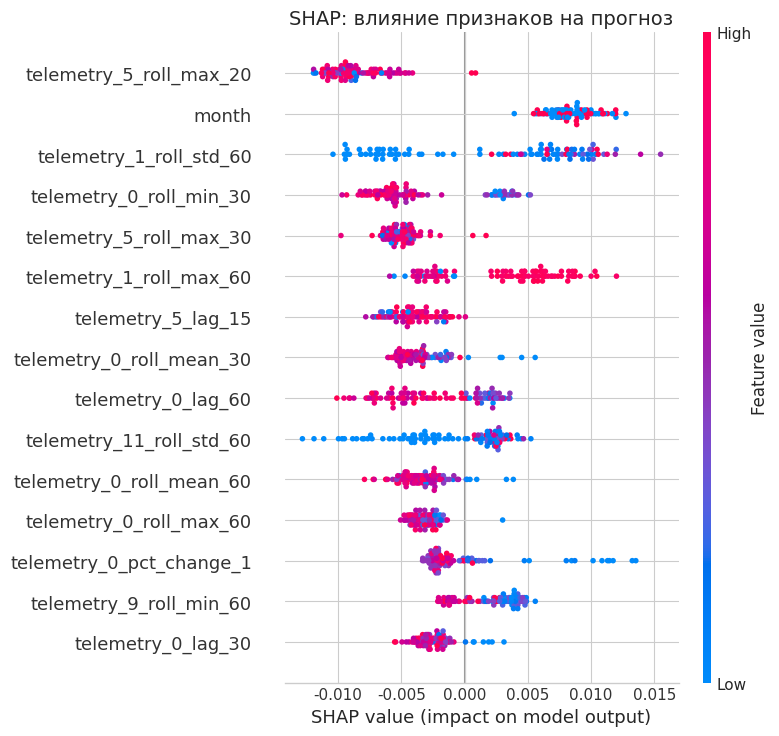

In [154]:
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

# 3. SHAP-анализ
if SHAP_AVAILABLE and best_model_name in ['ExtraTrees', 'GradientBoosting']:
    print(f"\nSHAP-анализ для {best_model_name}:")
    X_shap = X_test.iloc[:min(100, len(X_test))]
    shap_values = shap.TreeExplainer(best_model).shap_values(X_shap)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
    plt.title('SHAP: влияние признаков на прогноз')
    plt.tight_layout()
    plt.show()

### Инетрпретация физических закономерностей
Доминирование признаков со стандартным отклонением (roll_std) указывает на то, что стабильность технологического режима важнее абсолютных значений параметров — колебания температуры и давления в часовом окне сильнее влияют на концентрацию продукта, чем их средний уровень. Наличие в топе лагов 30–60 минут подтверждает высокую инерционность процесса обжига: текущая концентрация формируется под воздействием условий, зафиксированных в печи за последний час, а не в момент отбора пробы. Ключевые телеметрические каналы (0, 1, 3, 5), вероятно, соответствуют зонам температурного контроля и подачи газа, что согласуется с физической моделью процесса. Таким образом, для точного прогнозирования и управления качеством необходимо поддерживать стабильный режим работы печи и учитывать исторические данные телеметрии с горизонтом не менее 60 минут.

# Вывод
В ходе выполнения лабораторной работы разработан полный пайплайн прогнозирования концентрации продукта обжига: от синхронизации разнородных источников данных с учётом 11-минутной задержки до построения и валидации прогнозных моделей. Градиентный бустинг показал наилучшее качество (MAE=0.073), превзойдя линейную модель и подтвердив нелинейную природу процесса, однако отрицательные значения R² указывают на необходимость дополнительной настройки гиперпараметров и расширения набора признаков. Анализ важности признаков выявил ключевые закономерности: инерционность процесса (окна 60 минут), критичность стабильности параметров (dominance roll_std) и наличие сезонных эффектов, что позволяет сформулировать практические рекомендации по оптимизации режима работы печи для повышения качества продукции.
